In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy.sparse import hstack
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [71]:
data = pd.read_csv("NETFLIX.csv")

In [72]:
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [73]:
data.shape

(7787, 12)

In [74]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [75]:
data.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [76]:
data.isnull().sum

<bound method DataFrame.sum of       show_id   type  title  director   cast  country  date_added  \
0       False  False  False      True  False    False       False   
1       False  False  False     False  False    False       False   
2       False  False  False     False  False    False       False   
3       False  False  False     False  False    False       False   
4       False  False  False     False  False    False       False   
...       ...    ...    ...       ...    ...      ...         ...   
7782    False  False  False     False  False    False       False   
7783    False  False  False     False  False    False       False   
7784    False  False  False      True  False     True       False   
7785    False  False  False      True  False    False       False   
7786    False  False  False     False   True    False       False   

      release_year  rating  duration  listed_in  description  
0            False   False     False      False        False  
1            False   False     False      False        False  
2            False   False     False      False        False  
3            False   False     False      False        False  
4            False   False     False      False        False  
...            ...     ...       ...        ...          ...  
7782         False   False     False      False        False  
7783         False   False     False      False        False  
7784         False   False     False      False        False  
7785         False   False     False      False        False  
7786         False   False     False      False        False  

[7787 rows x 12 columns]>

In [77]:
data.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [78]:
data["director"] = data["director"].fillna("unknown")
data["cast"] = data["cast"].fillna("not available")
data["country"] = data["country"].fillna(data["country"].mode()[0])

data.dropna(subset = ["date_added" ,"rating" ], inplace= True)

In [79]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [80]:
current_year = 2026
data["content_year"] = current_year - data["release_year"]

In [81]:
data[["release_year" ,"content_year"]]

,release_year,content_year
0,2020,6
1,2016,10
2,2011,15
3,2009,17
4,2008,18
...,...,...
7782,2005,21
7783,2015,11
7784,2019,7
7785,2019,7


In [82]:
data['duration_num'] = data['duration'].str.extract(r'(\d+)')
data['duration_num'] = data['duration_num'].astype(float)

In [83]:
data[["duration" , "duration_num"]]

,duration,duration_num
0,4 Seasons,4.0
1,93 min,93.0
2,78 min,78.0
3,80 min,80.0
4,123 min,123.0
...,...,...
7782,99 min,99.0
7783,111 min,111.0
7784,44 min,44.0
7785,1 Season,1.0


In [84]:
features = data[['type','rating','release_year',
                 'duration_num','content_year',
                 'listed_in','description']]


In [85]:
features

,type,rating,release_year,duration_num,content_year,listed_in,description
0,TV Show,TV-MA,2020,4.0,6,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,Movie,TV-MA,2016,93.0,10,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,Movie,R,2011,78.0,15,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,Movie,PG-13,2009,80.0,17,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,Movie,PG-13,2008,123.0,18,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...
7782,Movie,TV-MA,2005,99.0,21,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,Movie,TV-14,2015,111.0,11,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,Movie,TV-MA,2019,44.0,7,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,TV Show,TV-PG,2019,1.0,7,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [86]:
tfidf = TfidfVectorizer(stop_words='english', max_features=500)

text_features = tfidf.fit_transform(
    features['listed_in'] + " " + features['description']
)

In [87]:
categorical_cols = ['type','rating']
numeric_cols = ['release_year','duration_num'	,'content_year']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

structured_features = preprocessor.fit_transform(features)


In [88]:
X = hstack([structured_features, text_features])

In [89]:
#K-Means

inv = []

for i in range (2 , 21):
  km =KMeans(n_clusters = i)
  km.fit(X)
  inv.append(km.inertia_)



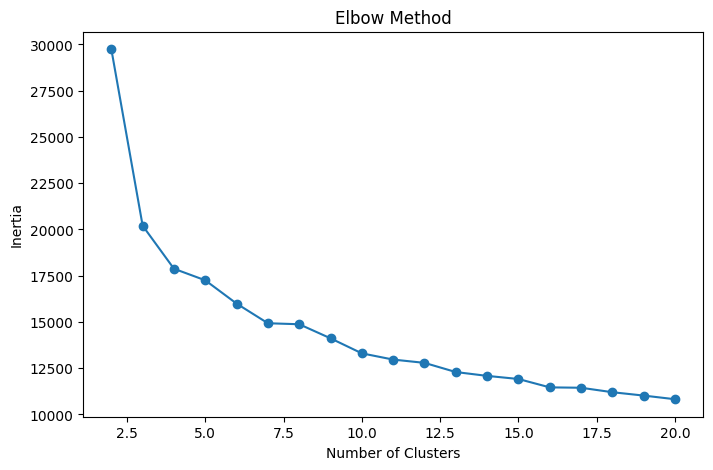

In [90]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 21), inv, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [91]:
import plotly.express as px

px.line(

    x = range(2, 21),
    y = inv,
    markers = True
)

In [92]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X)

data['Cluster'] = clusters


In [93]:
data.groupby('Cluster')['type'].value_counts()


Cluster  type   
0        TV Show    2344
         Movie        28
1        Movie      2649
2        Movie      1730
3        Movie       196
         TV Show      15
4        Movie       769
         TV Show      39
Name: count, dtype: int64

In [94]:
data.groupby('Cluster')['listed_in'].value_counts().head(10)


Cluster  listed_in                                                 
0        Kids' TV                                                      193
         International TV Shows, TV Dramas                             111
         Crime TV Shows, International TV Shows, TV Dramas             106
         International TV Shows, Romantic TV Shows, TV Dramas           86
         Kids' TV, TV Comedies                                          86
         Reality TV                                                     82
         International TV Shows, Romantic TV Shows, TV Comedies         79
         Docuseries                                                     71
         Anime Series, International TV Shows                           70
         International TV Shows, Korean TV Shows, Romantic TV Shows     65
Name: count, dtype: int64

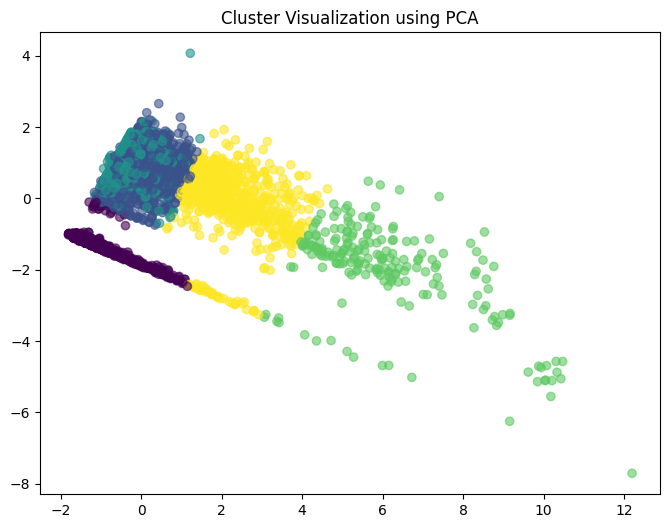

In [95]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=clusters, cmap='viridis', alpha=0.6)
plt.title("Cluster Visualization using PCA")
plt.show()


In [96]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_score = silhouette_score(X, clusters)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.20861117721647718


In [97]:
db_index = davies_bouldin_score(X.toarray(), clusters)
print("Davies-Bouldin Index:", db_index)


Davies-Bouldin Index: 1.6291379656118115


In [98]:
px.scatter(
    data_frame = data,
    x="duration_num",
    y="content_year",
    color="Cluster"
)